In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

%matplotlib ipympl

In [2]:
# 학습 데이터 생성 (Feature Augmentation 자동 처리)
bias = 100
X0, y, w = make_regression(
    n_samples=100, n_features=2, bias=bias,
    noise=10, coef=True, random_state=1)
print("이론적 관계:")
print("y = %.2f + %.2f*x1 + %.2f*x2" % (bias, w[0], w[1]))

이론적 관계:
y = 100.00 + 32.27*x1 + 86.45*x2


In [3]:
# scikit-learn의 linear regression
model = LinearRegression()
result = model.fit(X0, y)

print("추정한 관계:")
w = result.coef_
print("y = %.2f + %.2f*x1 + %.2f*x2" % (result.intercept_, w[0], w[1]))

추정한 관계:
y = 100.73 + 31.31*x1 + 83.68*x2


In [4]:
# 신규 데이터에 대한 예측
X_new = [[0.012345, -0.104532], [-0.16539, 0.15843]]
yhat = result.predict(X_new)
print("{0}에 대한 예측치: {1}".format(X_new, yhat))

[[0.012345, -0.104532], [-0.16539, 0.15843]]에 대한 예측치: [ 92.36983533 108.80932525]


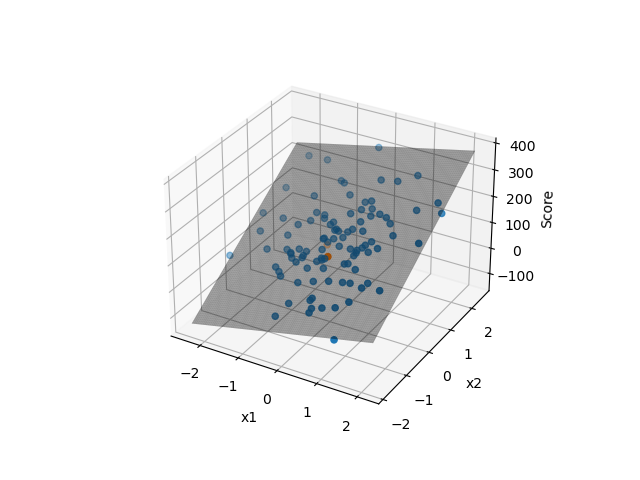

In [5]:
# 그래프 출력
X1_new = np.linspace(np.min(X0[:,0]), np.max(X0[:,0]), 100)
X2_new = np.linspace(np.min(X0[:,1]), np.max(X0[:,1]), 100)
m, n = np.meshgrid(X1_new, X2_new)

ax = plt.axes(projection='3d')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('Score')
ax.scatter(X0[:,0], X0[:,1], y)

x1 = [i[0] for i in X_new]
x2 = [i[1] for i in X_new]
ax.scatter(x1, x2, yhat)

z = m*w[0] + n*w[1] + result.intercept_
ax.plot_surface(m, n, z, rstride=1, cstride=1, color='none', alpha=0.4)
plt.show()